# Customer Single View & Designing Customer Data Platform

สร้าง Customer Single View (CSV) จากข้อมูลหลายแหล่ง เพื่อเตรียมข้อมูลสำหรับ Customer Analytics

## 1. โหลดข้อมูล

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix Thai font rendering — force Tahoma
import matplotlib.font_manager as fm
fm.fontManager.addfont(r'C:\Windows\Fonts\tahoma.ttf')
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.sans-serif'] = ['Tahoma'] + plt.rcParams.get('font.sans-serif', [])
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')


sns.set_style('whitegrid')


sns.set_style('whitegrid')
%matplotlib inline

In [2]:
customers    = pd.read_csv('../data/sample/customers.csv', parse_dates=['registration_date'])
transactions = pd.read_csv('../data/sample/transactions.csv', parse_dates=['transaction_date'])
products     = pd.read_csv('../data/sample/products.csv')

print(f'Customers:     {customers.shape}')
print(f'Transactions:  {transactions.shape}')
print(f'Products:      {products.shape}')

Customers:     (500, 6)
Transactions:  (8000, 7)
Products:      (25, 4)


In [3]:
customers.head()

,customer_id,age,gender,income,city,registration_date
0,C0001,69,Female,109018,Chiang Mai,2020-08-16
1,C0002,43,Male,139457,Chiang Mai,2022-05-31
2,C0003,39,Female,178189,Bangkok,2021-09-16
3,C0004,56,Female,46910,Bangkok,2020-01-07
4,C0005,19,Male,141888,Chonburi,2021-07-23


In [4]:
transactions.head()

,transaction_id,customer_id,product_id,amount,quantity,transaction_date,channel
0,T04888,C0128,P025,561.50,5,2021-01-01,Mobile
1,T06260,C0022,P051,579.69,9,2021-01-01,Online
2,T06351,C0406,P069,956.60,4,2021-01-01,Offline
3,T05696,C0044,P057,200.61,4,2021-01-01,Offline
4,T06145,C0139,P045,1273.02,5,2021-01-01,Mobile


In [5]:
products.head()

,product_id,product_name,category,price
0,P001,CLEANSER,Skincare,1903.97
1,P002,SERUM,Skincare,4756.04
2,P003,MOISTURIZER,Skincare,3673.37
3,P004,SUNSCREEN,Skincare,3013.36
4,P005,TONER,Skincare,822.29


## 2. Data Quality Check

In [6]:
print('=== Customers ===')
print(customers.isnull().sum())
print('\n=== Transactions ===')
print(transactions.isnull().sum())
print('\n=== Products ===')
print(products.isnull().sum())

=== Customers ===
customer_id          0
age                  0
gender               0
income               0
city                 0
registration_date    0
dtype: int64

=== Transactions ===
transaction_id      0
customer_id         0
product_id          0
amount              0
quantity            0
transaction_date    0
channel             0
dtype: int64

=== Products ===
product_id      0
product_name    0
category        0
price           0
dtype: int64


In [7]:
print(f'Unique customers in transactions: {transactions["customer_id"].nunique()}')
print(f'Customers without transactions: {len(set(customers["customer_id"]) - set(transactions["customer_id"]))}')

Unique customers in transactions: 500
Customers without transactions: 0


## 3. Feature Engineering — Customer Single View

In [8]:
# — Aggregate transaction features —
avg = transactions.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (x.max() - x.min()).days),
    frequency=('transaction_id', 'count'),
    monetary=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    first_txn=('transaction_date', 'min'),
    last_txn=('transaction_date', 'max'),
).reset_index()
avg['recency'] = avg['recency'].clip(lower=0)
print(avg.head())

  customer_id  recency  frequency  monetary   avg_amount  max_amount  \
0       C0001     1088         16  19696.66  1231.041250     3402.71   
1       C0002      857         15  22330.18  1488.678667     2615.49   
2       C0003     1202         16  19324.58  1207.786250     2644.28   
3       C0004      907         16  13937.08   871.067500     2487.19   
4       C0005     1076         22  20339.90   924.540909     2697.18   

   first_txn   last_txn  
0 2021-01-16 2024-01-09  
1 2022-02-02 2024-06-08  
2 2021-01-17 2024-05-03  
3 2021-07-16 2024-01-09  
4 2021-04-07 2024-03-18  


In [9]:
# — Channel preference —
channel_pivot = transactions.pivot_table(
    index='customer_id', columns='channel', values='amount', aggfunc='count', fill_value=0
).add_prefix('channel_')
channel_pivot['preferred_channel'] = channel_pivot.idxmax(axis=1)
channel_pivot.head()

channel,channel_Mobile,channel_Offline,channel_Online,preferred_channel
customer_id,,,,
C0001,4,6,6,channel_Offline
C0002,2,10,3,channel_Offline
C0003,2,6,8,channel_Online
C0004,3,5,8,channel_Online
C0005,5,10,7,channel_Offline


In [10]:
csv = customers.merge(avg, on='customer_id', how='left').merge(channel_pivot, on='customer_id', how='left')
csv.fillna({'frequency':0,'monetary':0,'avg_amount':0,'max_amount':0}, inplace=True)
print(f'CSV shape: {csv.shape}')
csv.head()

CSV shape: (500, 17)


,customer_id,age,gender,income,city,registration_date,recency,frequency,monetary,avg_amount,max_amount,first_txn,last_txn,channel_Mobile,channel_Offline,channel_Online,preferred_channel
0,C0001,69,Female,109018,Chiang Mai,2020-08-16,1088,16,19696.66,1231.041250,3402.71,2021-01-16,2024-01-09,4,6,6,channel_Offline
1,C0002,43,Male,139457,Chiang Mai,2022-05-31,857,15,22330.18,1488.678667,2615.49,2022-02-02,2024-06-08,2,10,3,channel_Offline
2,C0003,39,Female,178189,Bangkok,2021-09-16,1202,16,19324.58,1207.786250,2644.28,2021-01-17,2024-05-03,2,6,8,channel_Online
3,C0004,56,Female,46910,Bangkok,2020-01-07,907,16,13937.08,871.067500,2487.19,2021-07-16,2024-01-09,3,5,8,channel_Online
4,C0005,19,Male,141888,Chonburi,2021-07-23,1076,22,20339.90,924.540909,2697.18,2021-04-07,2024-03-18,5,10,7,channel_Offline


## 4. Visualize CSV Features

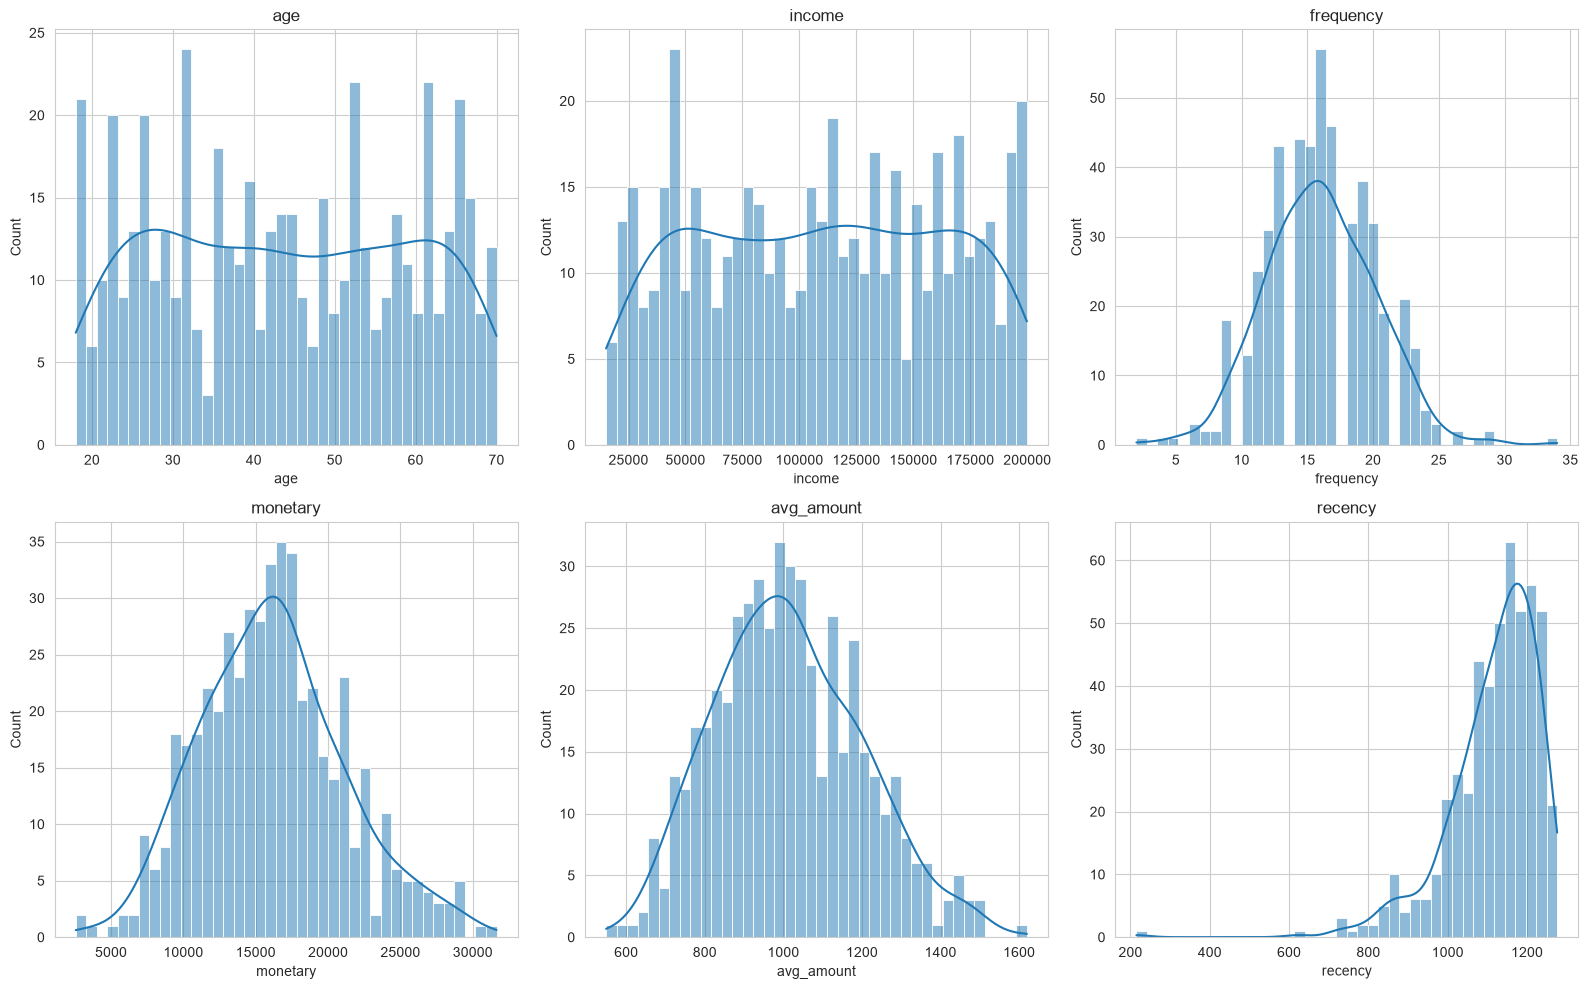

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols = ['age','income','frequency','monetary','avg_amount','recency']
for ax, col in zip(axes.flat, cols):
    sns.histplot(csv[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../data/sample/csv_distributions.png', dpi=100)
plt.show()

## 5. สรุป

✅ Customer Single View สร้างสำเร็จ — มีข้อมูล 500 customers พร้อม 12 features พร้อมนำไปใช้วิเคราะห์ต่อ (CLV, Churn, Segmentation)